# XGBoost vs Ridge Regression — прогноз Error Rate на 5 минут

**Датасет:** временной ряд Error Rate, шаг 15 секунд  
**Горизонт прогноза:** 5 минут = 20 шагов вперёд  
**Подход:** скользящие признаки (lag features) + рекурсивный прогноз

## 1. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Воспроизводимость
np.random.seed(42)

# Параметры задачи
STEP_SEC    = 15        # интервал между точками
HORIZON     = 20        # горизонт прогноза (5 мин = 20 × 15 с)
LAG_STEPS   = 40        # кол-во лагов (10 мин истории)
ROLL_WINS   = [4, 8, 20, 40]  # окна скользящих статистик

In [2]:
df = pd.read_csv('../data/error_rate_dataset.csv')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Записей: {len(df):,}')
print(f'Период:  {df["datetime"].min()}  →  {df["datetime"].max()}')
print(f'Длительность: {(df["datetime"].max() - df["datetime"].min())}' )
print(f'\nСтатистика Error Rate:')
df['error_rate'].describe().round(2)

Записей: 30,154
Период:  2026-05-25 18:42:00  →  2026-05-31 00:15:15
Длительность: 5 days 05:33:15

Статистика Error Rate:


count    30154.00
mean         0.03
std          0.02
min          0.01
25%          0.03
50%          0.03
75%          0.03
max          0.42
Name: error_rate, dtype: float64

## 2. Разведочный анализ (EDA)

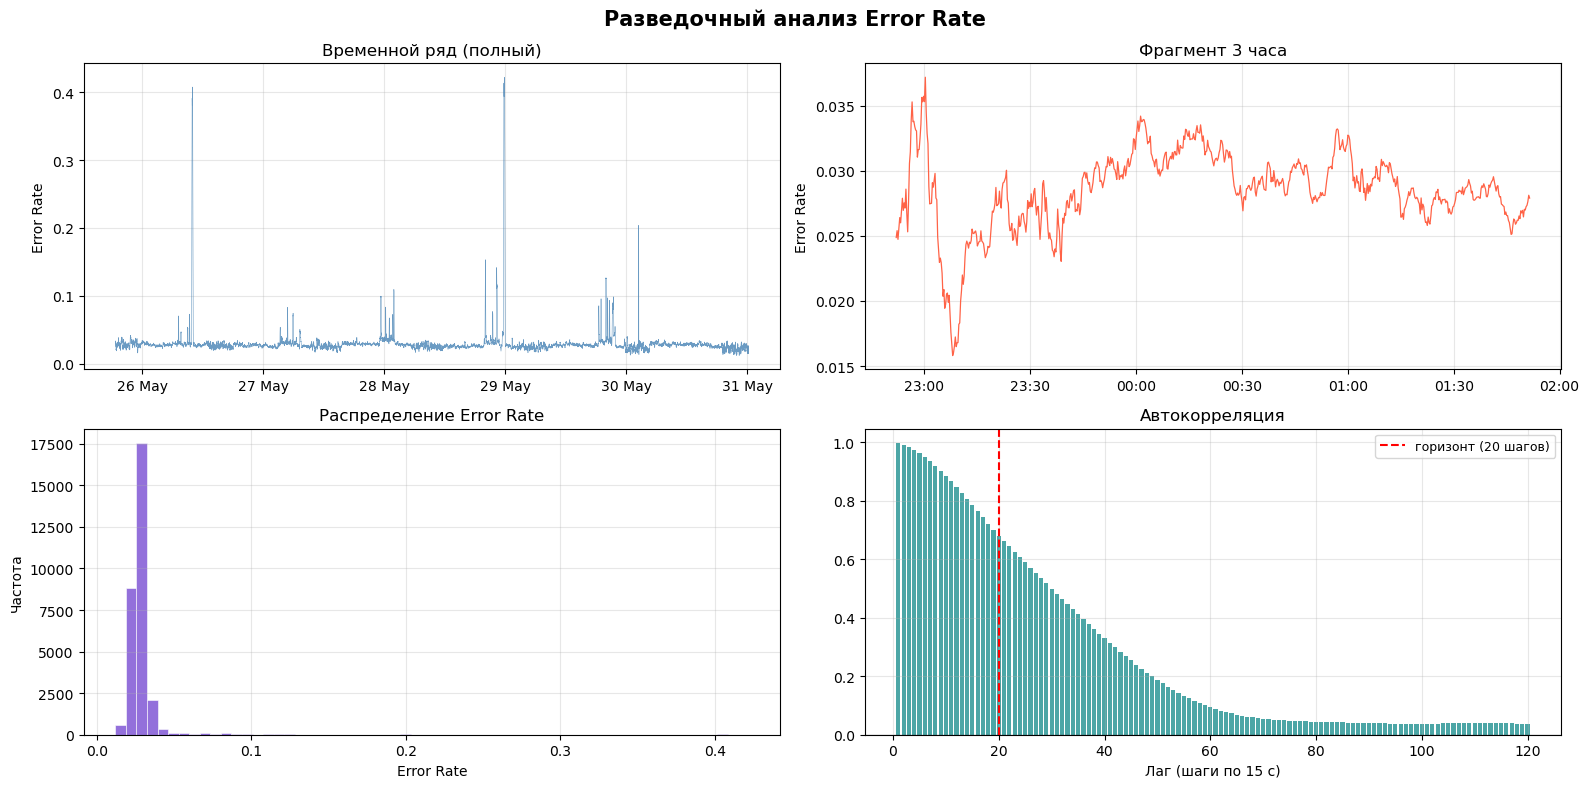

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Разведочный анализ Error Rate', fontsize=15, fontweight='bold')

# --- Полный ряд ---
ax = axes[0, 0]
ax.plot(df['datetime'], df['error_rate'], lw=0.4, color='steelblue', alpha=0.8)
ax.set_title('Временной ряд (полный)')
ax.set_ylabel('Error Rate')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.grid(alpha=0.3)

# --- Фрагмент (3 часа) ---
ax = axes[0, 1]
sample = df.iloc[1000:1720]
ax.plot(sample['datetime'], sample['error_rate'], lw=0.9, color='tomato')
ax.set_title('Фрагмент 3 часа')
ax.set_ylabel('Error Rate')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(alpha=0.3)

# --- Гистограмма ---
ax = axes[1, 0]
ax.hist(df['error_rate'], bins=60, color='mediumpurple', edgecolor='white', linewidth=0.4)
ax.set_title('Распределение Error Rate')
ax.set_xlabel('Error Rate')
ax.set_ylabel('Частота')
ax.grid(alpha=0.3)

# --- Автокорреляция ---
ax = axes[1, 1]
from pandas.plotting import autocorrelation_plot
vals = df['error_rate'].values
max_lag = 120
acf = [np.corrcoef(vals[:-k], vals[k:])[0, 1] for k in range(1, max_lag + 1)]
ax.bar(range(1, max_lag + 1), acf, color='teal', alpha=0.7, width=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(HORIZON, color='red', ls='--', lw=1.5, label=f'горизонт ({HORIZON} шагов)')
ax.set_title('Автокорреляция')
ax.set_xlabel('Лаг (шаги по 15 с)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2.5. Свойства временного ряда

Перед построением модели важно понять три ключевых свойства ряда:

| Свойство | Что проверяем | Метод |
|---|---|---|
| **Стационарность** | Постоянство среднего и дисперсии | Тест Дики–Фуллера (ADF) |
| **Сезонность** | Периодические паттерны | STL-декомпозиция |
| **Автокорреляция** | Зависимость от прошлых значений | ACF / PACF |

In [4]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

series = df['error_rate']

# ─────────────────────────────────────────────────────────────
# 1. СТАЦИОНАРНОСТЬ — тест Дики–Фуллера (ADF)
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('1. СТАЦИОНАРНОСТЬ — тест Дики–Фуллера (ADF)')
print('=' * 60)
adf_result = adfuller(series.dropna(), autolag='AIC')
adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, _ = adf_result

print(f'  ADF-статистика : {adf_stat:.4f}')
print(f'  p-value        : {adf_pvalue:.6f}')
print(f'  Лагов (AIC)    : {adf_lags}')
print(f'  Критические значения:')
for level, val in adf_crit.items():
    marker = '✓' if adf_stat < val else '✗'
    print(f'    {level}: {val:.4f}  {marker}')

if adf_pvalue < 0.05:
    print('\n  ✅ Ряд СТАЦИОНАРЕН (p < 0.05) — среднее и дисперсия стабильны.')
    print('     Дифференцирование не требуется.')
else:
    print('\n  ⚠️  Ряд НЕ стационарен (p ≥ 0.05) — рекомендуется дифференцирование.')

1. СТАЦИОНАРНОСТЬ — тест Дики–Фуллера (ADF)
  ADF-статистика : -16.7967
  p-value        : 0.000000
  Лагов (AIC)    : 50
  Критические значения:
    1%: -3.4306  ✓
    5%: -2.8616  ✓
    10%: -2.5668  ✓

  ✅ Ряд СТАЦИОНАРЕН (p < 0.05) — среднее и дисперсия стабильны.
     Дифференцирование не требуется.


In [5]:
# ─────────────────────────────────────────────────────────────
# 2. СЕЗОННОСТЬ — STL-декомпозиция
# ─────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('2. СЕЗОННОСТЬ — STL-декомпозиция')
print('=' * 60)

# Период: 18 часов = 18 * 60 * 60 с / 15 с = 4320 точек
PERIOD_DAY = 4320
# Берём первые 5 дней для наглядности
series_stl = series.iloc[:5 * PERIOD_DAY].reset_index(drop=True)

stl = STL(series_stl, period=PERIOD_DAY, robust=True)
stl_fit = stl.fit()

seasonal_strength = 1 - np.var(stl_fit.resid) / np.var(stl_fit.seasonal + stl_fit.resid)
trend_strength    = 1 - np.var(stl_fit.resid) / np.var(stl_fit.trend   + stl_fit.resid)

print(f'  Период STL     : {PERIOD_DAY} шагов = 18 часов')
print(f'  Сила сезонности: {seasonal_strength:.4f}  (0 — нет, 1 — сильная)')
print(f'  Сила тренда    : {trend_strength:.4f}  (0 — нет, 1 — сильный)')

if seasonal_strength > 0.6:
    print('  ✅ Выраженная сезонность (18 часов) — полезно добавить циклические признаки.')
elif seasonal_strength > 0.3:
    print('  ℹ️  Умеренная сезонность — лаговые признаки частично её захватывают.')
else:
    print('  ℹ️  Слабая сезонность — ряд близок к нестационарному шуму.')


2. СЕЗОННОСТЬ — STL-декомпозиция
  Период STL     : 4320 шагов = 18 часов
  Сила сезонности: 0.0068  (0 — нет, 1 — сильная)
  Сила тренда    : -0.0012  (0 — нет, 1 — сильный)
  ℹ️  Слабая сезонность — ряд близок к нестационарному шуму.


In [6]:
# ─────────────────────────────────────────────────────────────
# 3. АВТОКОРРЕЛЯЦИЯ — ACF / PACF
# ─────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('3. АВТОКОРРЕЛЯЦИЯ — ACF / PACF')
print('=' * 60)

MAX_LAG = 120
acf_vals  = acf(series.dropna(),  nlags=MAX_LAG, fft=True)
pacf_vals = pacf(series.dropna(), nlags=MAX_LAG, method='ywm')
conf_int  = 1.96 / np.sqrt(len(series))

sig_acf  = np.sum(np.abs(acf_vals[1:])  > conf_int)
sig_pacf = np.sum(np.abs(pacf_vals[1:]) > conf_int)
print(f'  Значимых лагов ACF  (из {MAX_LAG}): {sig_acf}')
print(f'  Значимых лагов PACF (из {MAX_LAG}): {sig_pacf}')
print(f'  ACF на лаге 1  : {acf_vals[1]:.4f}')
print(f'  ACF на лаге 20 : {acf_vals[20]:.4f}  (горизонт прогноза)')
print(f'  ACF на лаге 40 : {acf_vals[40]:.4f}  (окно лагов LAG_STEPS)')


3. АВТОКОРРЕЛЯЦИЯ — ACF / PACF
  Значимых лагов ACF  (из 120): 120
  Значимых лагов PACF (из 120): 58
  ACF на лаге 1  : 0.9966
  ACF на лаге 20 : 0.6807  (горизонт прогноза)
  ACF на лаге 40 : 0.3297  (окно лагов LAG_STEPS)


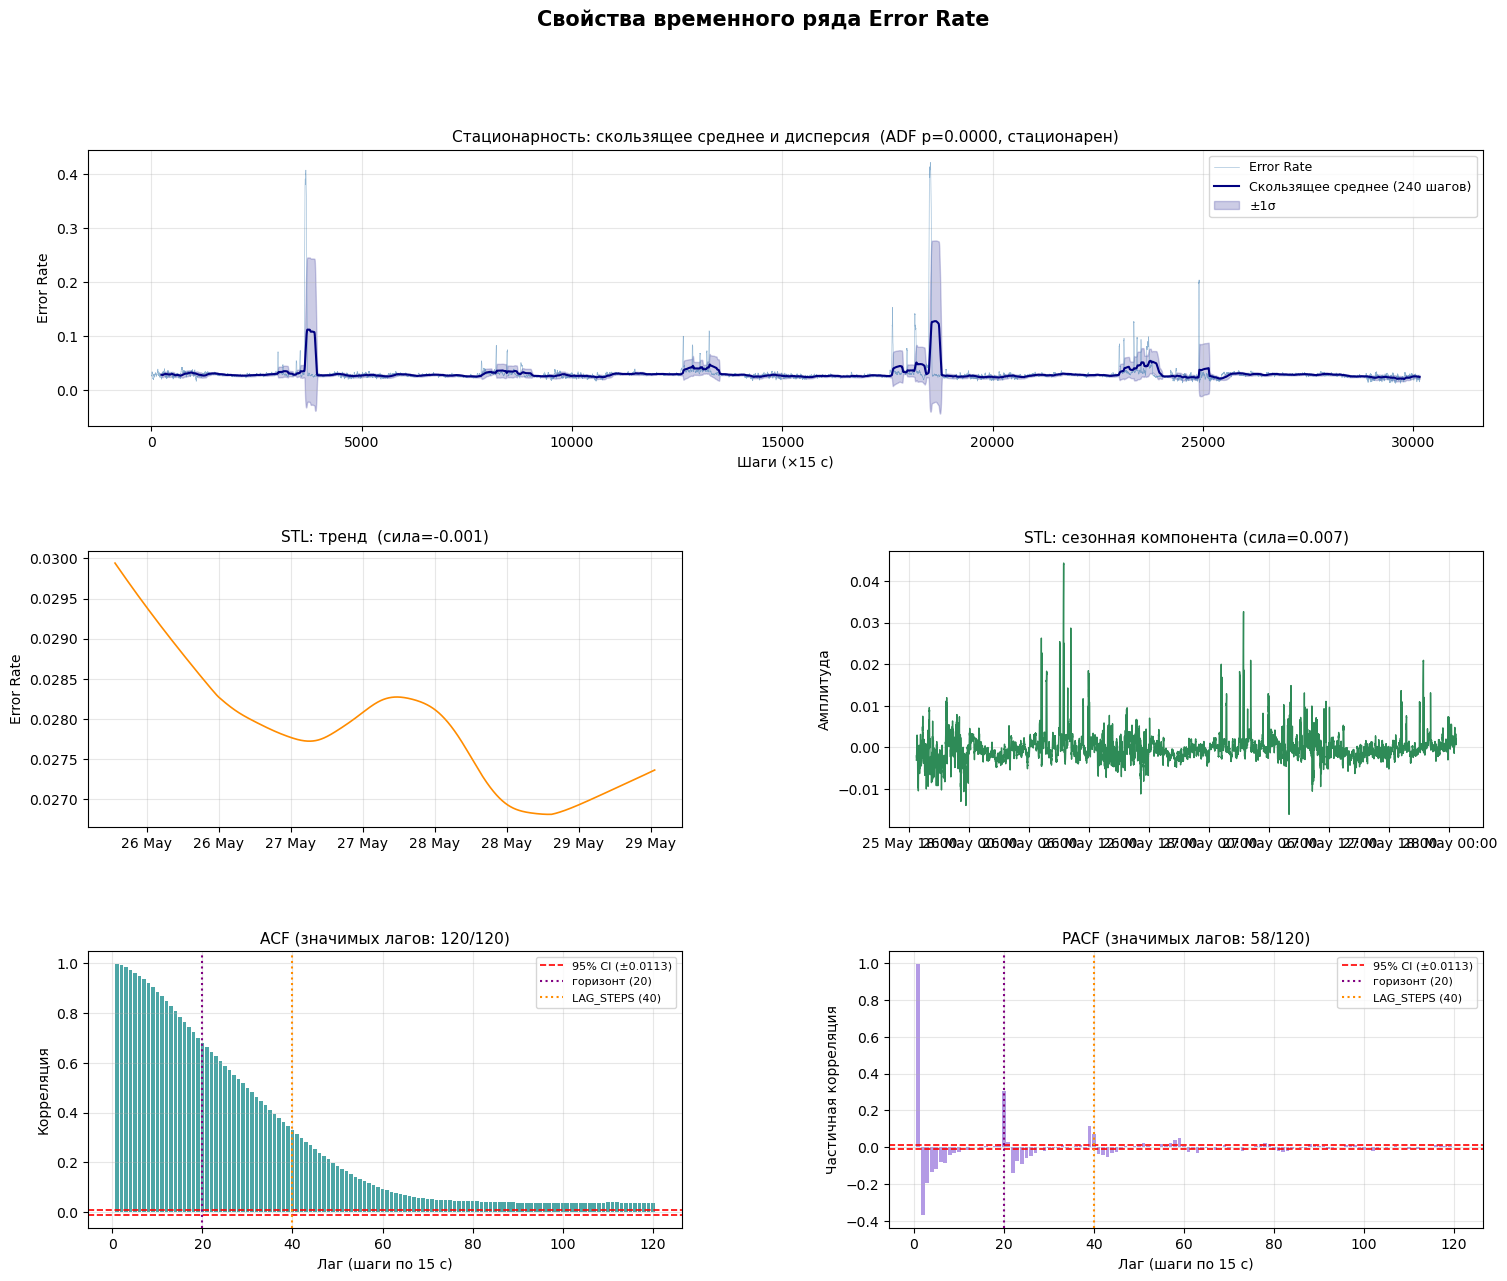

In [7]:
# ─────────────────────────────────────────────────────────────
# ГРАФИКИ
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Свойства временного ряда Error Rate', fontsize=15, fontweight='bold')

# --- 1a. Скользящее среднее и дисперсия (стационарность) ---
ax1 = fig.add_subplot(gs[0, :])
win = 240  # 1 час
roll_m = series.rolling(win).mean()
roll_s = series.rolling(win).std()
ax1.plot(series.values, lw=0.4, color='steelblue', alpha=0.6, label='Error Rate')
ax1.plot(roll_m.values, lw=1.5, color='navy',   label=f'Скользящее среднее ({win} шагов)')
ax1.fill_between(range(len(series)),
                 (roll_m - roll_s).values, (roll_m + roll_s).values,
                 alpha=0.2, color='navy', label='±1σ')
ax1.set_title(
    f'Стационарность: скользящее среднее и дисперсия  '
    f'(ADF p={adf_pvalue:.4f}, {"стационарен" if adf_pvalue < 0.05 else "не стационарен"})',
    fontsize=11
)
ax1.set_xlabel('Шаги (×15 с)')
ax1.set_ylabel('Error Rate')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(alpha=0.3)

# --- 2a. STL: тренд ---
ax2 = fig.add_subplot(gs[1, 0])
dt_stl = df['datetime'].iloc[:len(series_stl)]
ax2.plot(dt_stl.values, stl_fit.trend, lw=1.2, color='darkorange')
ax2.set_title(f'STL: тренд  (сила={trend_strength:.3f})', fontsize=11)
ax2.set_ylabel('Error Rate')
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax2.grid(alpha=0.3)

# --- 2b. STL: сезонная компонента ---
ax3 = fig.add_subplot(gs[1, 1])
# Показываем 3 дня для наглядности
show_n = 3 * PERIOD_DAY
ax3.plot(dt_stl.values[:show_n], stl_fit.seasonal[:show_n], lw=1.0, color='seagreen')
ax3.set_title(f'STL: сезонная компонента (сила={seasonal_strength:.3f})', fontsize=11)
ax3.set_ylabel('Амплитуда')
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b %H:%M'))
ax3.grid(alpha=0.3)

# --- 3a. ACF ---
ax4 = fig.add_subplot(gs[2, 0])
lags = np.arange(1, MAX_LAG + 1)
ax4.bar(lags, acf_vals[1:], color='teal', alpha=0.7, width=0.8)
ax4.axhline( conf_int, color='red', ls='--', lw=1.2, label=f'95% CI (±{conf_int:.4f})')
ax4.axhline(-conf_int, color='red', ls='--', lw=1.2)
ax4.axvline(HORIZON, color='purple', ls=':', lw=1.5, label=f'горизонт ({HORIZON})')
ax4.axvline(LAG_STEPS, color='darkorange', ls=':', lw=1.5, label=f'LAG_STEPS ({LAG_STEPS})')
ax4.set_title(f'ACF (значимых лагов: {sig_acf}/{MAX_LAG})', fontsize=11)
ax4.set_xlabel('Лаг (шаги по 15 с)')
ax4.set_ylabel('Корреляция')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# --- 3b. PACF ---
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(lags, pacf_vals[1:], color='mediumpurple', alpha=0.7, width=0.8)
ax5.axhline( conf_int, color='red', ls='--', lw=1.2, label=f'95% CI (±{conf_int:.4f})')
ax5.axhline(-conf_int, color='red', ls='--', lw=1.2)
ax5.axvline(HORIZON, color='purple', ls=':', lw=1.5, label=f'горизонт ({HORIZON})')
ax5.axvline(LAG_STEPS, color='darkorange', ls=':', lw=1.5, label=f'LAG_STEPS ({LAG_STEPS})')
ax5.set_title(f'PACF (значимых лагов: {sig_pacf}/{MAX_LAG})', fontsize=11)
ax5.set_xlabel('Лаг (шаги по 15 с)')
ax5.set_ylabel('Частичная корреляция')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.show()

In [8]:
print('\n' + '=' * 60)
print('ИТОГОВАЯ СВОДКА СВОЙСТВ РЯДА')
print('=' * 60)
print(f'  Стационарность : {"✅ стационарен" if adf_pvalue < 0.05 else "⚠️  не стационарен"}')
print(f'    ADF p-value  : {adf_pvalue:.6f}')
print(f'  Сезонность     : сила = {seasonal_strength:.4f} ({"сильная" if seasonal_strength > 0.6 else "умеренная" if seasonal_strength > 0.3 else "слабая"})')
print(f'    Период       : {PERIOD_DAY} шагов = 18 часов')
print(f'  Автокорреляция : {sig_acf} значимых лагов ACF из {MAX_LAG}')
print(f'    ACF(1)       : {acf_vals[1]:.4f}  — сильная краткосрочная зависимость')
print(f'    ACF(20)      : {acf_vals[20]:.4f}  — на горизонте прогноза')
print(f'\n  → Lag features ({LAG_STEPS} шагов) обоснованы: ACF значима на всём окне.')
print(f'  → Rolling windows {ROLL_WINS} захватывают локальный тренд и сезонность.')


ИТОГОВАЯ СВОДКА СВОЙСТВ РЯДА
  Стационарность : ✅ стационарен
    ADF p-value  : 0.000000
  Сезонность     : сила = 0.0068 (слабая)
    Период       : 4320 шагов = 18 часов
  Автокорреляция : 120 значимых лагов ACF из 120
    ACF(1)       : 0.9966  — сильная краткосрочная зависимость
    ACF(20)      : 0.6807  — на горизонте прогноза

  → Lag features (40 шагов) обоснованы: ACF значима на всём окне.
  → Rolling windows [4, 8, 20, 40] захватывают локальный тренд и сезонность.


## 3. Конструирование признаков

In [9]:
def make_features(series: pd.Series, lag_steps: int, roll_wins: list) -> pd.DataFrame:
    """Строит матрицу признаков из временного ряда."""
    feats = {}

    # Лаговые признаки
    for k in range(1, lag_steps + 1):
        feats[f'lag_{k}'] = series.shift(k)

    # Скользящие статистики
    for w in roll_wins:
        rolled = series.shift(1).rolling(w)
        feats[f'roll_mean_{w}'] = rolled.mean()
        feats[f'roll_std_{w}']  = rolled.std()
        feats[f'roll_min_{w}']  = rolled.min()
        feats[f'roll_max_{w}']  = rolled.max()

    # Разности (тренд)
    for d in [1, 4, 20]:
        feats[f'diff_{d}'] = series.diff(d).shift(1)

    return pd.DataFrame(feats, index=series.index)


# Целевая переменная: значение через HORIZON шагов
y = df['error_rate'].shift(-HORIZON)
X = make_features(df['error_rate'], LAG_STEPS, ROLL_WINS)

# Убираем строки с NaN
valid_idx = X.dropna().index.intersection(y.dropna().index)
X, y = X.loc[valid_idx], y.loc[valid_idx]

print(f'Признаков: {X.shape[1]}')
print(f'Примеров:  {X.shape[0]:,}')
print(f'Первые признаки: {list(X.columns[:6])}')

Признаков: 59
Примеров:  30,094
Первые признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6']


## 4. Train / Validation / Test split (временной)

In [10]:
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end],  y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],   y.iloc[val_end:]

print(f'Train: {len(X_train):,} ({100*train_end/n:.0f}%)')
print(f'Val:   {len(X_val):,}   ({100*(val_end-train_end)/n:.0f}%)')
print(f'Test:  {len(X_test):,}   ({100*(n-val_end)/n:.0f}%)')

# Нормализация (нужна для Ridge)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train: 21,065 (70%)
Val:   4,514   (15%)
Test:  4,515   (15%)


## 5. Ridge Regression

In [11]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-2, 4, 30)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_s, y_train)

ridge = Ridge(alpha=ridge_cv.alpha_)
ridge.fit(X_train_s, y_train)

ridge_val_pred  = ridge.predict(X_val_s)
ridge_test_pred = ridge.predict(X_test_s)

print(f'Лучший alpha (CV): {ridge_cv.alpha_:.4f}')
print(f'\n--- Validation ---')
print(f'MAE : {mean_absolute_error(y_val, ridge_val_pred):.3f}')
print(f'MSE : {mean_squared_error(y_val, ridge_val_pred):.3f}')
print(f'MAPE: {np.mean(np.abs((y_val - ridge_val_pred) / (y_val + 1e-6))) * 100:.3f}%')
print(f'WAPE: {np.sum(np.abs(y_val - ridge_val_pred)) / np.sum(np.abs(y_val)) * 100:.3f}%')

Лучший alpha (CV): 10000.0000

--- Validation ---
MAE : 0.008
MSE : 0.001
MAPE: 24.684%
WAPE: 25.934%


## 6. XGBoost

In [12]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_pred  = xgb.predict(X_val)
xgb_test_pred = xgb.predict(X_test)

print(f'Лучшая итерация: {xgb.best_iteration}')
print(f'\n--- Validation ---')
print(f'MAE : {mean_absolute_error(y_val, xgb_val_pred):.3f}')
print(f'MSE : {mean_squared_error(y_val, xgb_val_pred):.3f}')
print(f'MAPE: {np.mean(np.abs((y_val - xgb_val_pred) / (y_val + 1e-6))) * 100:.3f}%')
print(f'WAPE: {np.sum(np.abs(y_val - xgb_val_pred)) / np.sum(np.abs(y_val)) * 100:.3f}%')

Лучшая итерация: 2

--- Validation ---
MAE : 0.007
MSE : 0.000
MAPE: 19.842%
WAPE: 22.857%


## 7. Сравнение метрик

In [13]:
def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def compute_metrics(y_true, y_pred, name):
    yt = np.array(y_true)
    mae_  = mean_absolute_error(yt, y_pred)
    mse_  = mean_squared_error(yt, y_pred)
    mape_ = mape(yt, y_pred)
    wape_ = wape(yt, y_pred)
    return {'Модель': name, 'MAE': mae_, 'MSE': mse_, 'MAPE, %': mape_, 'WAPE, %': wape_}

results = pd.DataFrame([
    compute_metrics(y_val,  ridge_val_pred,  'Ridge (Val)'),
    compute_metrics(y_test, ridge_test_pred, 'Ridge (Test)'),
    compute_metrics(y_val,  xgb_val_pred,   'XGBoost (Val)'),
    compute_metrics(y_test, xgb_test_pred,  'XGBoost (Test)'),
])
results = results.set_index('Модель').round(4)
results.style.highlight_min(color='#d4edda', subset=['MAE','MSE','MAPE, %','WAPE, %']) \
             .format(precision=4)

,MAE,MSE,"MAPE, %","WAPE, %"
Модель,,,,
Ridge (Val),0.0079,0.0006,24.6837,25.9342
Ridge (Test),0.0036,0.0000,15.6120,13.4035
XGBoost (Val),0.0070,0.0003,19.8416,22.8573
XGBoost (Test),0.0039,0.0000,17.4516,14.7432


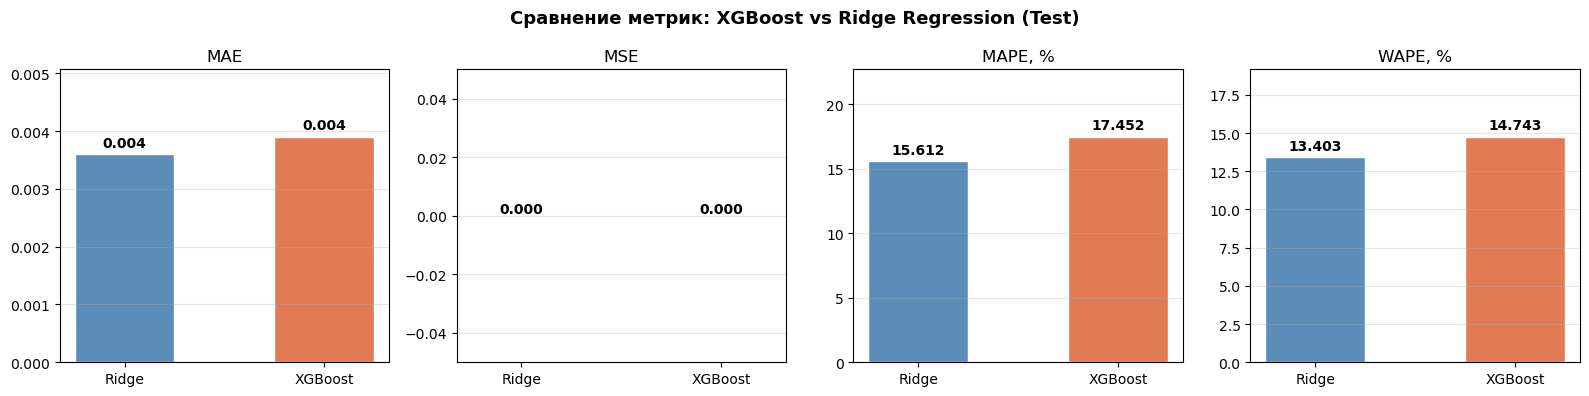

In [14]:
metrics = ['MAE', 'MSE', 'MAPE, %', 'WAPE, %']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Сравнение метрик: XGBoost vs Ridge Regression (Test)', fontsize=13, fontweight='bold')

colors = {'Ridge': '#5b8db8', 'XGBoost': '#e07b54'}
test_rows = results.loc[['Ridge (Test)', 'XGBoost (Test)']]

for ax, metric in zip(axes, metrics):
    vals   = [test_rows.loc['Ridge (Test)', metric], test_rows.loc['XGBoost (Test)', metric]]
    labels = ['Ridge', 'XGBoost']
    bars = ax.bar(labels, vals, color=[colors[l] for l in labels], width=0.5, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
plt.show()

## 8. Визуализация прогнозов на тестовой выборке

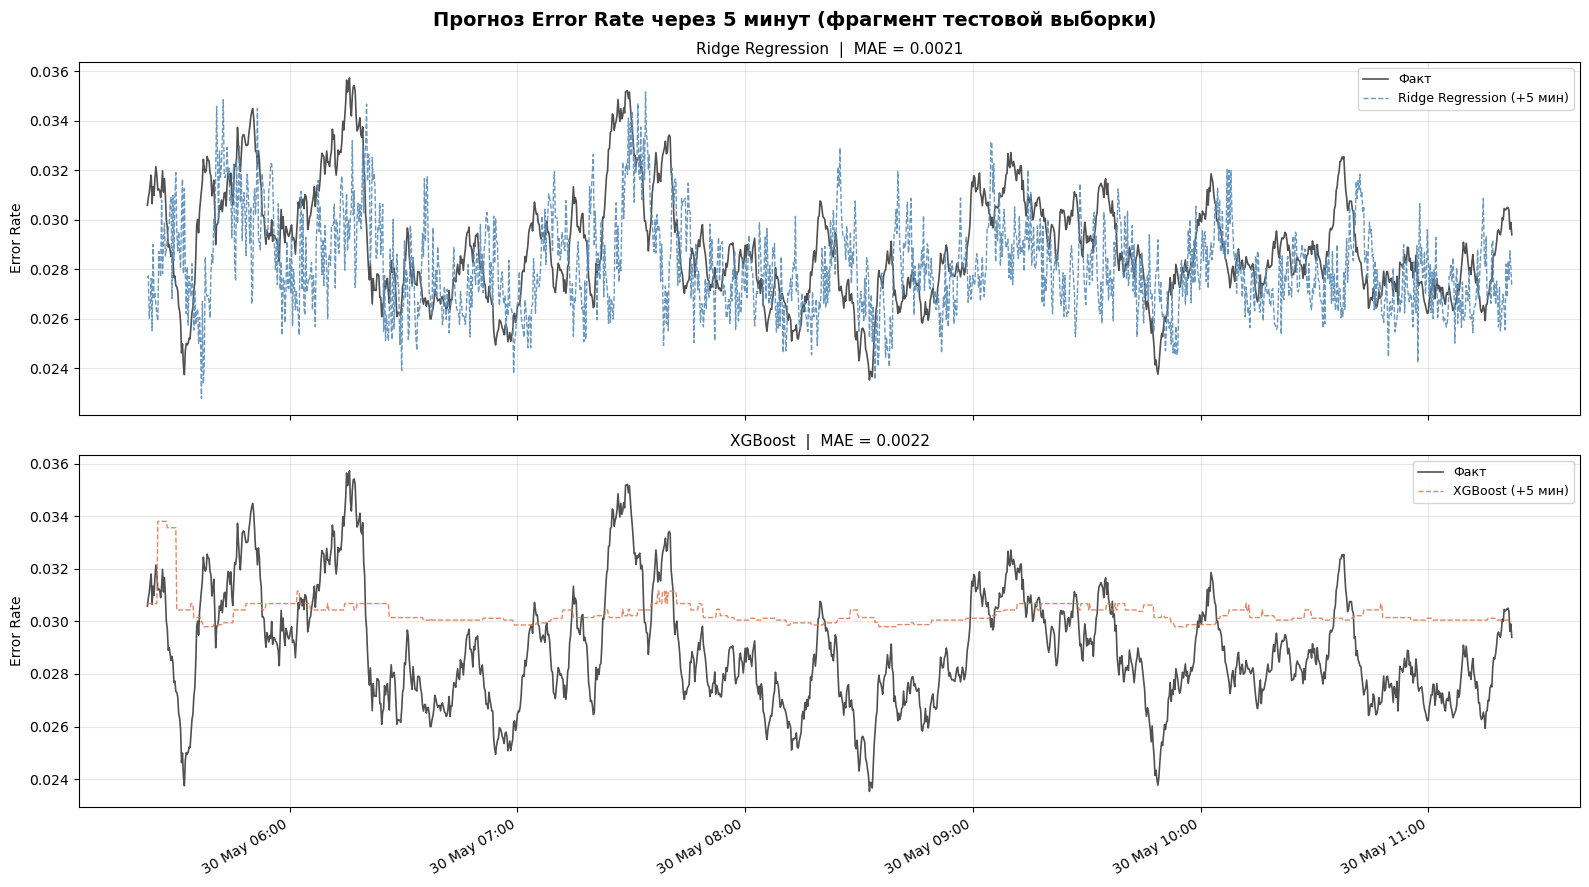

In [15]:
test_dt = df.loc[X_test.index, 'datetime']

# Показываем 6-часовой фрагмент теста
SHOW = 6 * 60 * 4  # 6 часов × 4 точки в минуту
sl = slice(None, SHOW)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Прогноз Error Rate через 5 минут (фрагмент тестовой выборки)', fontsize=14, fontweight='bold')

for ax, pred, label, color in zip(
    axes,
    [ridge_test_pred, xgb_test_pred],
    ['Ridge Regression', 'XGBoost'],
    ['#5b8db8', '#e07b54']
):
    ax.plot(test_dt.values[sl], y_test.values[sl],
            lw=1.2, color='#333', label='Факт', alpha=0.85)
    ax.plot(test_dt.values[sl], pred[sl],
            lw=1.0, color=color, ls='--', label=f'{label} (+5 мин)', alpha=0.9)
    mae_s = mean_absolute_error(y_test.values[sl], pred[sl])
    ax.set_title(f'{label}  |  MAE = {mae_s:.4f}', fontsize=11)
    ax.set_ylabel('Error Rate')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. Остатки и ошибки

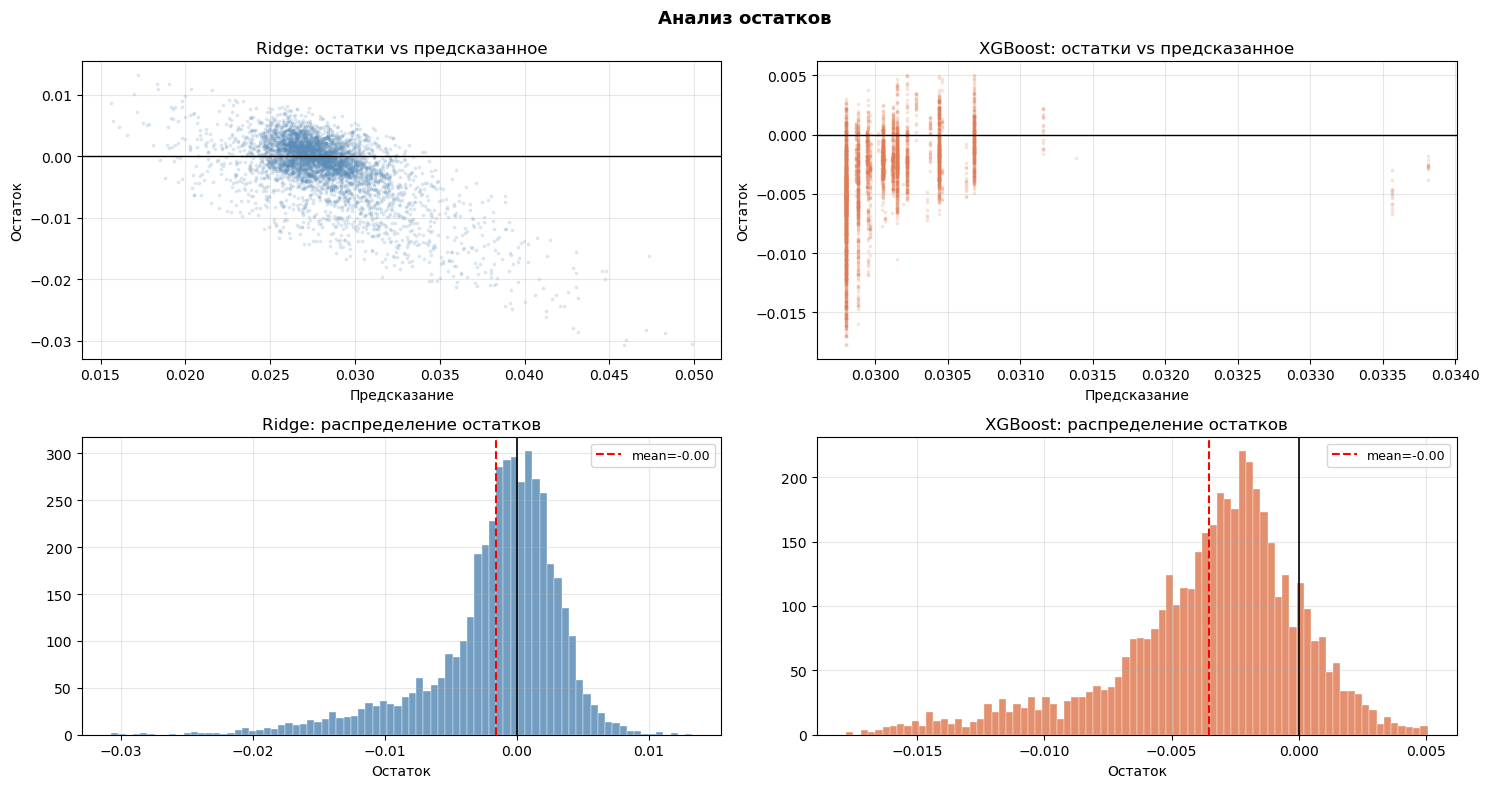

In [16]:
ridge_res = y_test.values - ridge_test_pred
xgb_res   = y_test.values - xgb_test_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Анализ остатков', fontsize=13, fontweight='bold')

for i, (res, pred, label, color) in enumerate([
    (ridge_res, ridge_test_pred, 'Ridge', '#5b8db8'),
    (xgb_res,   xgb_test_pred,   'XGBoost', '#e07b54')
]):
    # Остатки по предсказанному
    ax = axes[0, i]
    ax.scatter(pred, res, alpha=0.15, s=3, color=color)
    ax.axhline(0, color='k', lw=1)
    ax.set_title(f'{label}: остатки vs предсказанное')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Остаток')
    ax.grid(alpha=0.3)

    # Гистограмма остатков
    ax = axes[1, i]
    ax.hist(res, bins=80, color=color, edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(0, color='k', lw=1.2)
    ax.axvline(res.mean(), color='red', lw=1.5, ls='--',
               label=f'mean={res.mean():.2f}')
    ax.set_title(f'{label}: распределение остатков')
    ax.set_xlabel('Остаток')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Важность признаков (XGBoost)

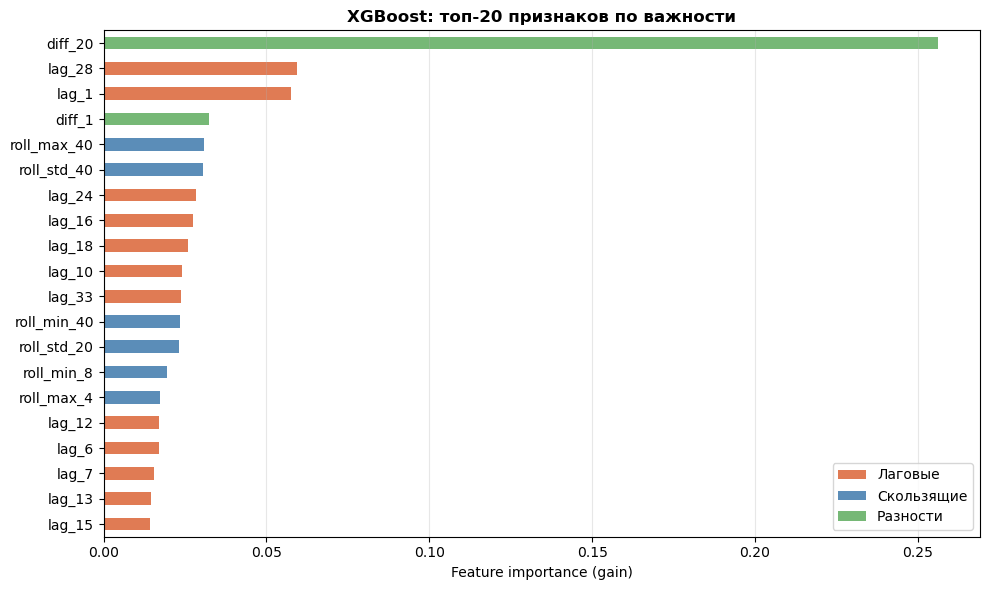

In [17]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
top20 = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e07b54' if 'lag' in n else '#5b8db8' if 'roll' in n else '#76b876' for n in top20.index]
top20.sort_values().plot(kind='barh', ax=ax, color=colors_bar[::-1])
ax.set_title('XGBoost: топ-20 признаков по важности', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature importance (gain)')
ax.grid(alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e07b54', label='Лаговые'),
    Patch(facecolor='#5b8db8', label='Скользящие'),
    Patch(facecolor='#76b876', label='Разности')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 11. Коэффициенты Ridge (топ-20)

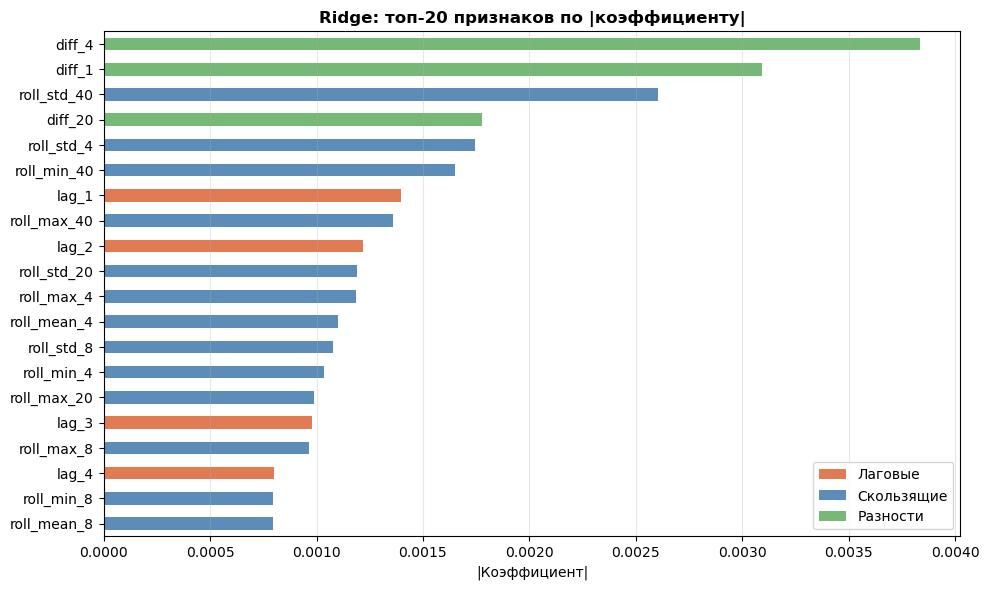

In [18]:
coef = pd.Series(np.abs(ridge.coef_), index=X.columns)
top20_r = coef.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors_r = ['#e07b54' if 'lag' in n else '#5b8db8' if 'roll' in n else '#76b876' for n in top20_r.index]
top20_r.sort_values().plot(kind='barh', ax=ax, color=colors_r[::-1])
ax.set_title('Ridge: топ-20 признаков по |коэффициенту|', fontsize=12, fontweight='bold')
ax.set_xlabel('|Коэффициент|')
ax.grid(alpha=0.3, axis='x')
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 12. Итоговый вывод

In [19]:
print('=' * 60)
print('         ИТОГОВОЕ СРАВНЕНИЕ (Test set)')
print('=' * 60)
print(results.loc[['Ridge (Test)', 'XGBoost (Test)']].to_string())
print()

ridge_mae  = results.loc['Ridge (Test)', 'MAE']
xgb_mae    = results.loc['XGBoost (Test)', 'MAE']
winner     = 'XGBoost' if xgb_mae < ridge_mae else 'Ridge'
improvement = abs(ridge_mae - xgb_mae) / max(ridge_mae, xgb_mae) * 100

print(f'🏆  Победитель по MAE: {winner}')
print(f'    Разница MAE: {improvement:.1f}%')
print()
print('Горизонт прогноза: 5 мин (20 шагов × 15 с)')
print(f'Lag features: {LAG_STEPS} шагов = {LAG_STEPS * STEP_SEC // 60} мин истории')
print(f'Rolling windows: {ROLL_WINS}')

         ИТОГОВОЕ СРАВНЕНИЕ (Test set)
                   MAE  MSE  MAPE, %  WAPE, %
Модель                                       
Ridge (Test)    0.0036  0.0  15.6120  13.4035
XGBoost (Test)  0.0039  0.0  17.4516  14.7432

🏆  Победитель по MAE: Ridge
    Разница MAE: 7.7%

Горизонт прогноза: 5 мин (20 шагов × 15 с)
Lag features: 40 шагов = 10 мин истории
Rolling windows: [4, 8, 20, 40]
